# RSR Paper Figures
Clean, publication-ready visualizations for BERT and GPT-2 RSR results.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Clean style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white'
})

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

# Load results
results_dir = Path('results')
bert_files = sorted(results_dir.glob('bert_seeds_*.xlsx'))
gpt2_files = sorted(results_dir.glob('gpt2_seeds_*.xlsx'))

df_bert = pd.read_excel(bert_files[-1]).dropna() if bert_files else None
df_gpt2 = pd.read_excel(gpt2_files[-1]).dropna() if gpt2_files else None

print(f"BERT: {len(df_bert)} seeds" if df_bert is not None else "No BERT data")
print(f"GPT-2: {len(df_gpt2)} seeds" if df_gpt2 is not None else "No GPT-2 data")

BERT: 10 seeds
GPT-2: 10 seeds


## Figure 1: Main Results
Shows RSR improvement across both models and all evaluation categories.

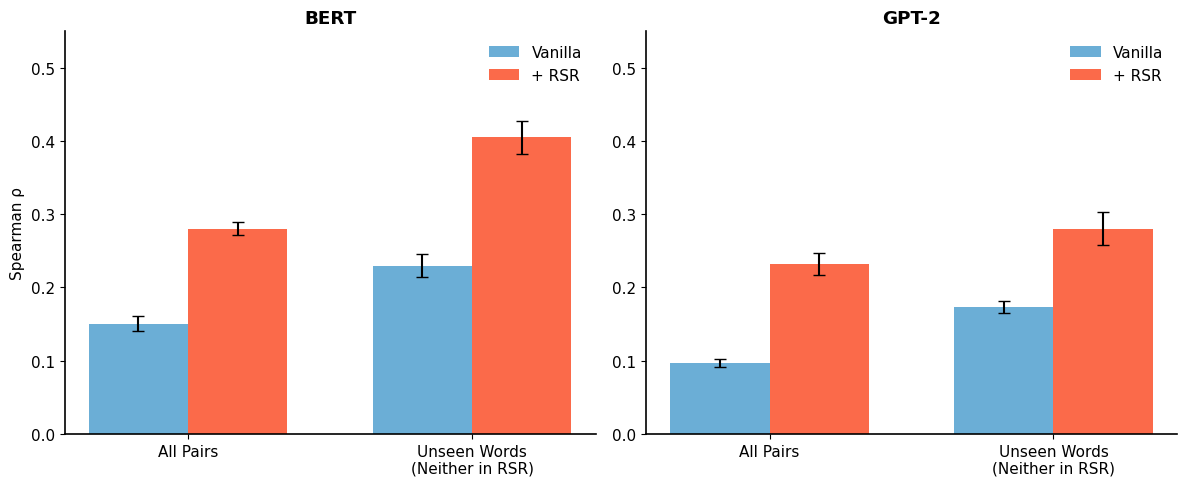

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cats = ['all', 'neither']
labels = ['All Pairs', 'Unseen Words\n(Neither in RSR)']
x = np.arange(len(cats))
w = 0.35

# BERT
ax = axes[0]
v_mean = [df_bert[f'vanilla_{c}'].mean() for c in cats]
v_std = [df_bert[f'vanilla_{c}'].std() for c in cats]
r_mean = [df_bert[f'rsr_{c}'].mean() for c in cats]
r_std = [df_bert[f'rsr_{c}'].std() for c in cats]

ax.bar(x - w/2, v_mean, w, yerr=v_std, label='Vanilla', color='#6BAED6', capsize=4)
ax.bar(x + w/2, r_mean, w, yerr=r_std, label='+ RSR', color='#FB6A4A', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Spearman ρ')
ax.set_title('BERT', fontweight='bold')
ax.set_ylim(0, 0.55)
ax.legend(frameon=False)

# GPT-2
ax = axes[1]
v_mean = [df_gpt2[f'vanilla_{c}'].mean() for c in cats]
v_std = [df_gpt2[f'vanilla_{c}'].std() for c in cats]
r_mean = [df_gpt2[f'rsr_{c}'].mean() for c in cats]
r_std = [df_gpt2[f'rsr_{c}'].std() for c in cats]

ax.bar(x - w/2, v_mean, w, yerr=v_std, label='Vanilla', color='#6BAED6', capsize=4)
ax.bar(x + w/2, r_mean, w, yerr=r_std, label='+ RSR', color='#FB6A4A', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('GPT-2', fontweight='bold')
ax.set_ylim(0, 0.55)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(fig_dir / 'fig1_main_results.pdf')
plt.savefig(fig_dir / 'fig1_main_results.png')
plt.show()

## Figure 2: RSR Improvement by Category
Highlights that RSR generalizes beyond training vocabulary.

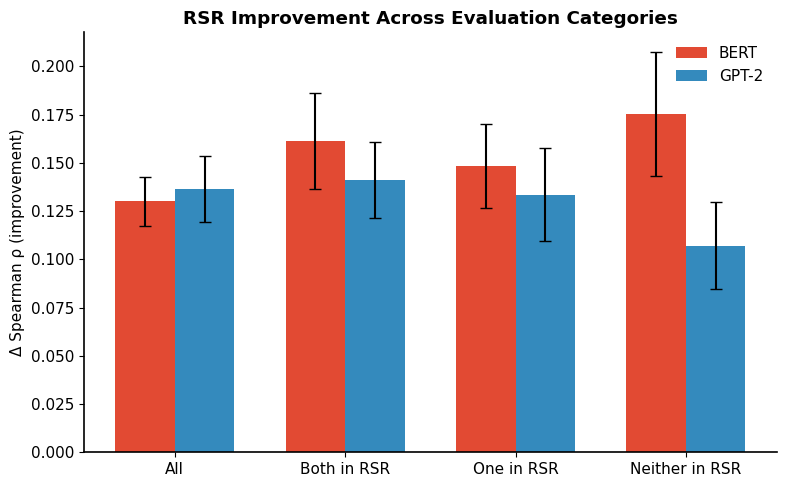

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

cats = ['all', 'both', 'one', 'neither']
labels = ['All', 'Both in RSR', 'One in RSR', 'Neither in RSR']
x = np.arange(len(cats))
w = 0.35

bert_delta = [df_bert[f'delta_{c}'].mean() for c in cats]
bert_err = [df_bert[f'delta_{c}'].std() for c in cats]
gpt2_delta = [df_gpt2[f'delta_{c}'].mean() for c in cats]
gpt2_err = [df_gpt2[f'delta_{c}'].std() for c in cats]

ax.bar(x - w/2, bert_delta, w, yerr=bert_err, label='BERT', color='#E24A33', capsize=4)
ax.bar(x + w/2, gpt2_delta, w, yerr=gpt2_err, label='GPT-2', color='#348ABD', capsize=4)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Δ Spearman ρ (improvement)')
ax.set_title('RSR Improvement Across Evaluation Categories', fontweight='bold')
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig(fig_dir / 'fig2_improvement_by_category.pdf')
plt.savefig(fig_dir / 'fig2_improvement_by_category.png')
plt.show()

## Figure 3: Robustness Across Seeds
Shows consistent improvement across random initializations.

## Figure 4: Before vs After RSR (Scatter with Lines)
Each point is a seed. Lines connect vanilla → RSR performance.

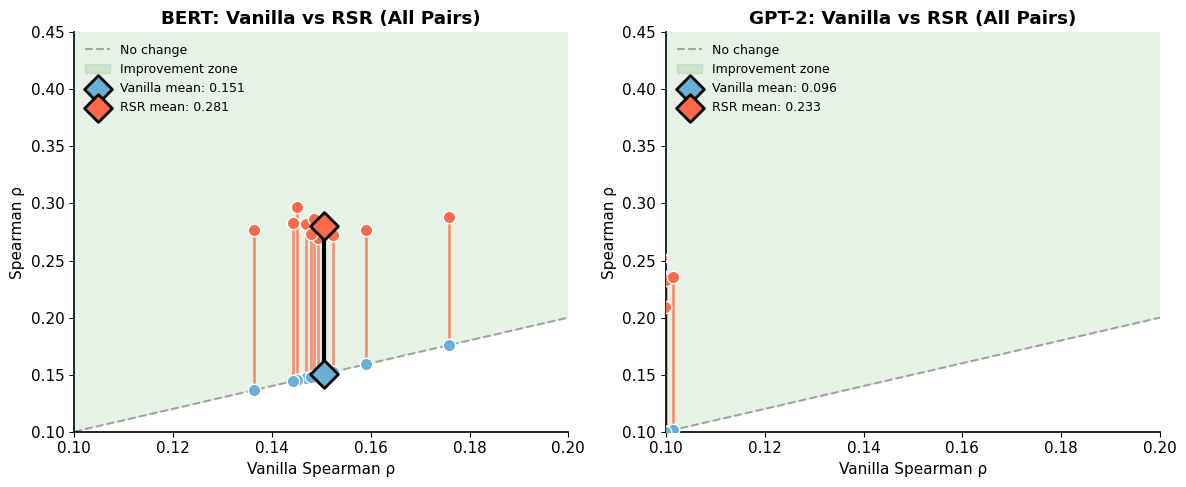

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, name in [(axes[0], df_bert, 'BERT'), (axes[1], df_gpt2, 'GPT-2')]:
    # Plot diagonal line (y=x, no improvement)
    lims = [0, 0.5]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='No change')
    ax.fill_between(lims, lims, [0.5, 0.5], alpha=0.1, color='green', label='Improvement zone')
    
    # Plot each seed as a point pair with connecting line
    for i in range(len(df)):
        van = df['vanilla_all'].iloc[i]
        rsr = df['rsr_all'].iloc[i]
        # Line connecting vanilla to RSR
        ax.plot([van, van], [van, rsr], color='#FB6A4A', linewidth=2, alpha=0.7)
        # Vanilla point (on diagonal)
        ax.scatter(van, van, color='#6BAED6', s=80, zorder=5, edgecolor='white', linewidth=1)
        # RSR point (above diagonal if improved)
        ax.scatter(van, rsr, color='#FB6A4A', s=80, zorder=5, edgecolor='white', linewidth=1)
    
    # Add mean markers
    van_mean = df['vanilla_all'].mean()
    rsr_mean = df['rsr_all'].mean()
    ax.scatter(van_mean, van_mean, color='#6BAED6', s=200, marker='D', edgecolor='black', linewidth=2, zorder=10, label=f'Vanilla mean: {van_mean:.3f}')
    ax.scatter(van_mean, rsr_mean, color='#FB6A4A', s=200, marker='D', edgecolor='black', linewidth=2, zorder=10, label=f'RSR mean: {rsr_mean:.3f}')
    ax.plot([van_mean, van_mean], [van_mean, rsr_mean], color='black', linewidth=3, zorder=9)
    
    ax.set_xlabel('Vanilla Spearman ρ')
    ax.set_ylabel('Spearman ρ')
    ax.set_title(f'{name}: Vanilla vs RSR (All Pairs)', fontweight='bold')
    ax.set_xlim(0.1, 0.2)
    ax.set_ylim(0.1, 0.45)
    ax.legend(loc='upper left', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(fig_dir / 'fig4_scatter_before_after.pdf')
plt.savefig(fig_dir / 'fig4_scatter_before_after.png')
plt.show()

## Figure 5: Slope Chart (Alternative Style)
Classic paired comparison - each line is one seed.

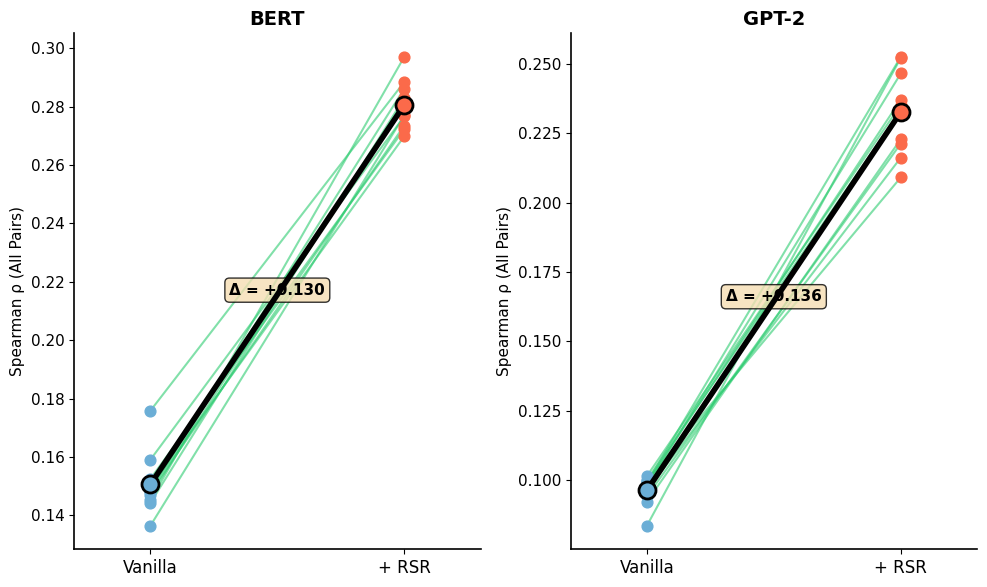

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

for ax, df, name in [(axes[0], df_bert, 'BERT'), (axes[1], df_gpt2, 'GPT-2')]:
    # Plot each seed as a line from Vanilla to RSR
    for i in range(len(df)):
        van = df['vanilla_all'].iloc[i]
        rsr = df['rsr_all'].iloc[i]
        color = '#2ecc71' if rsr > van else '#e74c3c'  # Green if improved
        ax.plot([0, 1], [van, rsr], color=color, linewidth=1.5, alpha=0.6)
        ax.scatter([0], [van], color='#6BAED6', s=60, zorder=5)
        ax.scatter([1], [rsr], color='#FB6A4A', s=60, zorder=5)
    
    # Mean line (thicker)
    van_mean = df['vanilla_all'].mean()
    rsr_mean = df['rsr_all'].mean()
    ax.plot([0, 1], [van_mean, rsr_mean], color='black', linewidth=4, zorder=10)
    ax.scatter([0], [van_mean], color='#6BAED6', s=150, zorder=11, edgecolor='black', linewidth=2)
    ax.scatter([1], [rsr_mean], color='#FB6A4A', s=150, zorder=11, edgecolor='black', linewidth=2)
    
    # Labels
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Vanilla', '+ RSR'], fontsize=12)
    ax.set_ylabel('Spearman ρ (All Pairs)')
    ax.set_title(f'{name}', fontweight='bold', fontsize=14)
    ax.set_xlim(-0.3, 1.3)
    
    # Annotation for mean improvement
    delta = rsr_mean - van_mean
    ax.annotate(f'Δ = {delta:+.3f}', xy=(0.5, (van_mean + rsr_mean)/2), 
                fontsize=11, ha='center', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(fig_dir / 'fig5_slope_chart.pdf')
plt.savefig(fig_dir / 'fig5_slope_chart.png')
plt.show()

## Figure 6: Performance Across Seeds (Line Plot)
X-axis = seed, Y-axis = Spearman ρ, comparing Vanilla vs RSR.

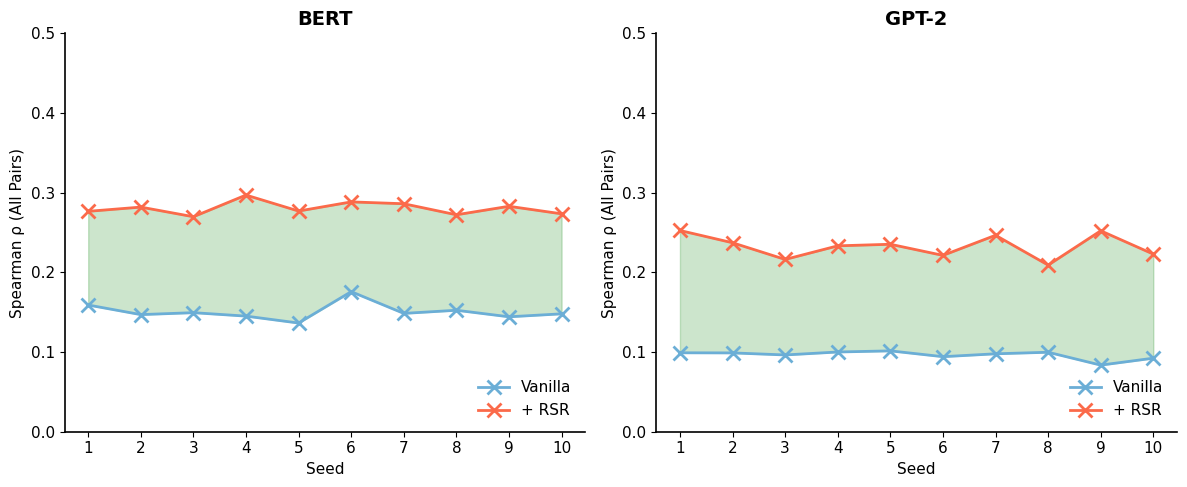

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, name in [(axes[0], df_bert, 'BERT'), (axes[1], df_gpt2, 'GPT-2')]:
    seeds = df['seed'].values
    vanilla = df['vanilla_all'].values
    rsr = df['rsr_all'].values
    
    # Vanilla line
    ax.plot(seeds, vanilla, marker='x', markersize=10, linewidth=2, 
            color='#6BAED6', label='Vanilla', markeredgewidth=2)
    
    # RSR line
    ax.plot(seeds, rsr, marker='x', markersize=10, linewidth=2,
            color='#FB6A4A', label='+ RSR', markeredgewidth=2)
    
    # Fill between to highlight improvement
    ax.fill_between(seeds, vanilla, rsr, alpha=0.2, color='green')
    
    ax.set_xlabel('Seed')
    ax.set_ylabel('Spearman ρ (All Pairs)')
    ax.set_title(f'{name}', fontweight='bold', fontsize=14)
    ax.set_xticks(seeds)
    ax.legend(loc='lower right', frameon=False)
    ax.set_ylim(0, 0.5)

plt.tight_layout()
plt.savefig(fig_dir / 'fig6_seeds_lineplot.pdf')
plt.savefig(fig_dir / 'fig6_seeds_lineplot.png')
plt.show()

## Word2Vec Interleaved Results (RSR Frequency = 10)
Comparing vanilla vs RSR Word2Vec with interleaved training (1 RSR step per 10 W2V steps).

In [17]:
# Load Word2Vec interleaved sweep results
w2v_sweep = pd.read_excel(results_dir / 'seed_results_interleaved_sweep.xlsx')

# Filter to RSR frequency = 10 (1 RSR step per 10 W2V steps)
df_w2v = w2v_sweep[w2v_sweep['rsr_frequency'] == 10].copy()
df_w2v = df_w2v.reset_index(drop=True)

print(f"Word2Vec (RSR freq=10): {len(df_w2v)} seeds")
print(f"  Vanilla mean: {df_w2v['vanilla_all'].mean():.3f}")
print(f"  RSR mean: {df_w2v['rsr_all'].mean():.3f}")
print(f"  Delta mean: {df_w2v['delta_all'].mean():+.3f}")

Word2Vec (RSR freq=10): 10 seeds
  Vanilla mean: 0.273
  RSR mean: 0.413
  Delta mean: +0.141


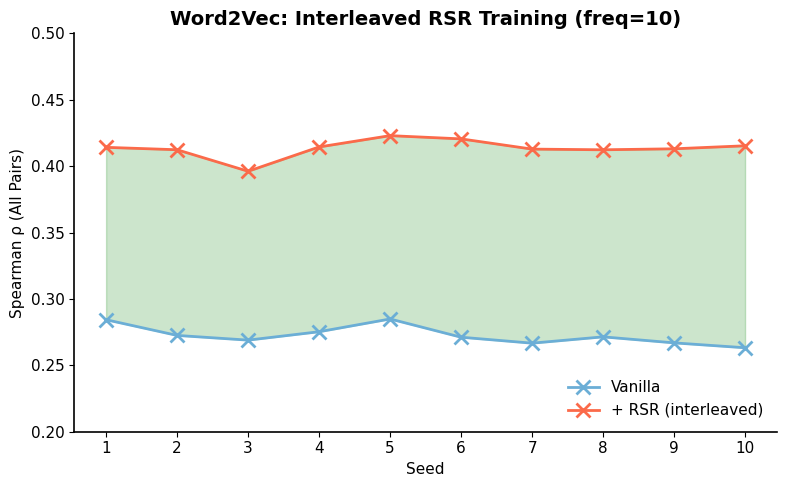

In [18]:
# Word2Vec: Line plot across seeds (same style as BERT/GPT-2)
fig, ax = plt.subplots(figsize=(8, 5))

seeds = df_w2v['seed'].values
vanilla = df_w2v['vanilla_all'].values
rsr = df_w2v['rsr_all'].values

# Vanilla line
ax.plot(seeds, vanilla, marker='x', markersize=10, linewidth=2, 
        color='#6BAED6', label='Vanilla', markeredgewidth=2)

# RSR line  
ax.plot(seeds, rsr, marker='x', markersize=10, linewidth=2,
        color='#FB6A4A', label='+ RSR (interleaved)', markeredgewidth=2)

# Fill between to highlight improvement
ax.fill_between(seeds, vanilla, rsr, alpha=0.2, color='green')

ax.set_xlabel('Seed')
ax.set_ylabel('Spearman ρ (All Pairs)')
ax.set_title('Word2Vec: Interleaved RSR Training (freq=10)', fontweight='bold', fontsize=14)
ax.set_xticks(seeds)
ax.legend(loc='lower right', frameon=False)
ax.set_ylim(0.2, 0.5)

plt.tight_layout()
plt.savefig(fig_dir / 'fig_w2v_interleaved_seeds.pdf')
plt.savefig(fig_dir / 'fig_w2v_interleaved_seeds.png')
plt.show()

In [19]:
# Word2Vec summary statistics
print("="*60)
print("WORD2VEC INTERLEAVED RSR RESULTS (freq=10)")
print("="*60)

print(f"\nVanilla: {df_w2v['vanilla_all'].mean():.3f} ± {df_w2v['vanilla_all'].std():.3f}")
print(f"RSR:     {df_w2v['rsr_all'].mean():.3f} ± {df_w2v['rsr_all'].std():.3f}")
print(f"Delta:   {df_w2v['delta_all'].mean():+.3f} ± {df_w2v['delta_all'].std():.3f}")
print(f"\nSeeds with positive Δ: {(df_w2v['delta_all'] > 0).sum()}/{len(df_w2v)}")

# Check if we have category breakdowns
if 'vanilla_0_train' in df_w2v.columns:
    print("\n--- By Category ---")
    print(f"Neither in RSR:  Δ = {df_w2v['delta_0_train'].mean():+.3f} ± {df_w2v['delta_0_train'].std():.3f}")
    print(f"One in RSR:      Δ = {df_w2v['delta_1_train'].mean():+.3f} ± {df_w2v['delta_1_train'].std():.3f}")
    print(f"Both in RSR:     Δ = {df_w2v['delta_2_train'].mean():+.3f} ± {df_w2v['delta_2_train'].std():.3f}")

WORD2VEC INTERLEAVED RSR RESULTS (freq=10)

Vanilla: 0.273 ± 0.007
RSR:     0.413 ± 0.007
Delta:   +0.141 ± 0.008

Seeds with positive Δ: 10/10

--- By Category ---
Neither in RSR:  Δ = -0.000 ± 0.013
One in RSR:      Δ = -0.005 ± 0.018
Both in RSR:     Δ = +0.368 ± 0.011


## All Three Models Combined
Side-by-side comparison of Word2Vec, BERT, and GPT-2.

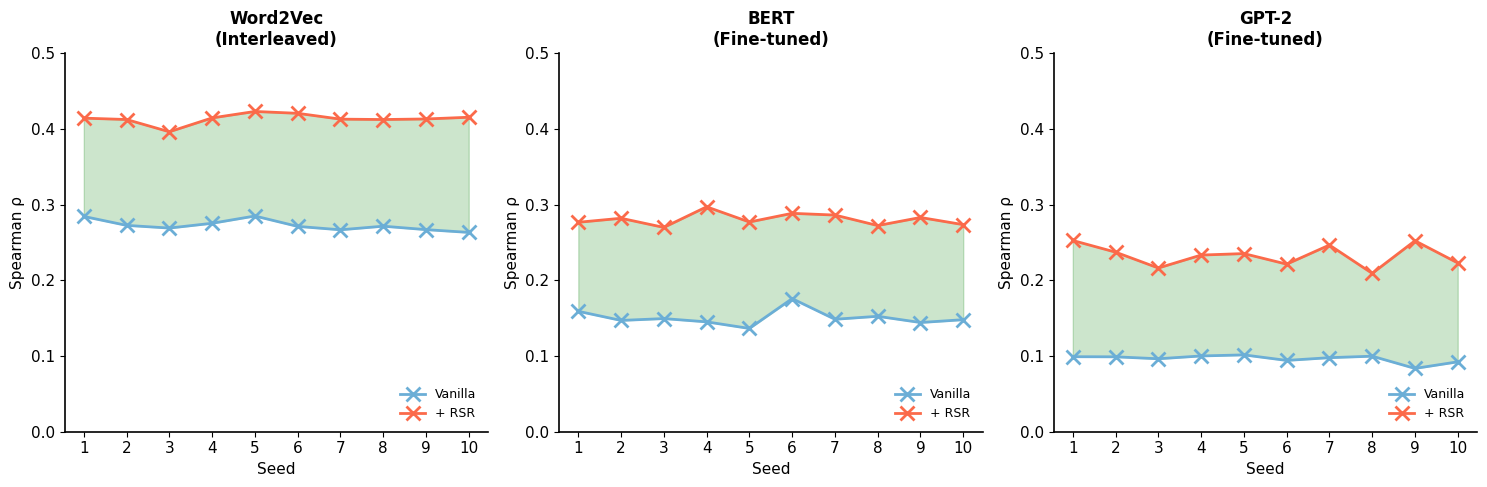

Saved: fig_all_models_seeds.png


In [ ]:
# Combined figure: All three models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (df_w2v, 'Word2Vec\n(Interleaved)', 'vanilla_all', 'rsr_all'),
    (df_bert, 'BERT\n(Fine-tuned)', 'vanilla_all', 'rsr_all'),
    (df_gpt2, 'GPT-2\n(Fine-tuned)', 'vanilla_all', 'rsr_all')
]

for ax, (df, title, van_col, rsr_col) in zip(axes, datasets):
    seeds = df['seed'].values
    vanilla = df[van_col].values
    rsr = df[rsr_col].values
    
    ax.plot(seeds, vanilla, marker='x', markersize=10, linewidth=2, 
            color='#6BAED6', label='Vanilla', markeredgewidth=2)
    ax.plot(seeds, rsr, marker='x', markersize=10, linewidth=2,
            color='#FB6A4A', label='+ RSR', markeredgewidth=2)
    ax.fill_between(seeds, vanilla, rsr, alpha=0.2, color='green')
    
    ax.set_xlabel('Seed')
    ax.set_ylabel('Spearman ρ')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks(seeds)
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    ax.set_ylim(0, 0.5)

plt.tight_layout()
plt.savefig(fig_dir / 'fig_all_models_seeds.pdf')
plt.savefig(fig_dir / 'fig_all_models_seeds.png')
plt.show()

print("Saved: fig_all_models_seeds.png")

In [21]:
# Combined summary table for all three models
print("="*70)
print("ALL MODELS COMPARISON (SimLex-999 All Pairs)")
print("="*70)

print(f"\n{'Model':<15} {'Vanilla':>12} {'RSR':>12} {'Δ':>12} {'Seeds+':>8}")
print("-"*60)

for name, df, van_col, rsr_col, delta_col in [
    ('Word2Vec', df_w2v, 'vanilla_all', 'rsr_all', 'delta_all'),
    ('BERT', df_bert, 'vanilla_all', 'rsr_all', 'delta_all'),
    ('GPT-2', df_gpt2, 'vanilla_all', 'rsr_all', 'delta_all'),
]:
    van = df[van_col].mean()
    rsr = df[rsr_col].mean()
    delta = df[delta_col].mean()
    positive = (df[delta_col] > 0).sum()
    total = len(df)
    print(f"{name:<15} {van:>12.3f} {rsr:>12.3f} {delta:>+12.3f} {positive:>4}/{total}")

print("\n" + "="*70)
print("LaTeX TABLE:")
print("="*70)
print(r"""\begin{table}[t]
\centering
\caption{SimLex-999 Spearman correlation across model architectures (10 seeds each).}
\begin{tabular}{lcccc}
\toprule
Model & Type & Vanilla $\rho$ & RSR $\rho$ & $\Delta$ \\
\midrule""")

print(f"Word2Vec & Static (interleaved) & {df_w2v['vanilla_all'].mean():.3f} & {df_w2v['rsr_all'].mean():.3f} & {df_w2v['delta_all'].mean():+.3f} \\\\")
print(f"BERT & Bidirectional (fine-tuned) & {df_bert['vanilla_all'].mean():.3f} & {df_bert['rsr_all'].mean():.3f} & {df_bert['delta_all'].mean():+.3f} \\\\")
print(f"GPT-2 & Autoregressive (fine-tuned) & {df_gpt2['vanilla_all'].mean():.3f} & {df_gpt2['rsr_all'].mean():.3f} & {df_gpt2['delta_all'].mean():+.3f} \\\\")

print(r"""\bottomrule
\end{tabular}
\end{table}""")

ALL MODELS COMPARISON (SimLex-999 All Pairs)

Model                Vanilla          RSR            Δ   Seeds+
------------------------------------------------------------
Word2Vec               0.273        0.413       +0.141   10/10
BERT                   0.151        0.281       +0.130   10/10
GPT-2                  0.096        0.233       +0.136   10/10

LaTeX TABLE:
\begin{table}[t]
\centering
\caption{SimLex-999 Spearman correlation across model architectures (10 seeds each).}
\begin{tabular}{lcccc}
\toprule
Model & Type & Vanilla $\rho$ & RSR $\rho$ & $\Delta$ \\
\midrule
Word2Vec & Static (interleaved) & 0.273 & 0.413 & +0.141 \\
BERT & Bidirectional (fine-tuned) & 0.151 & 0.281 & +0.130 \\
GPT-2 & Autoregressive (fine-tuned) & 0.096 & 0.233 & +0.136 \\
\bottomrule
\end{tabular}
\end{table}


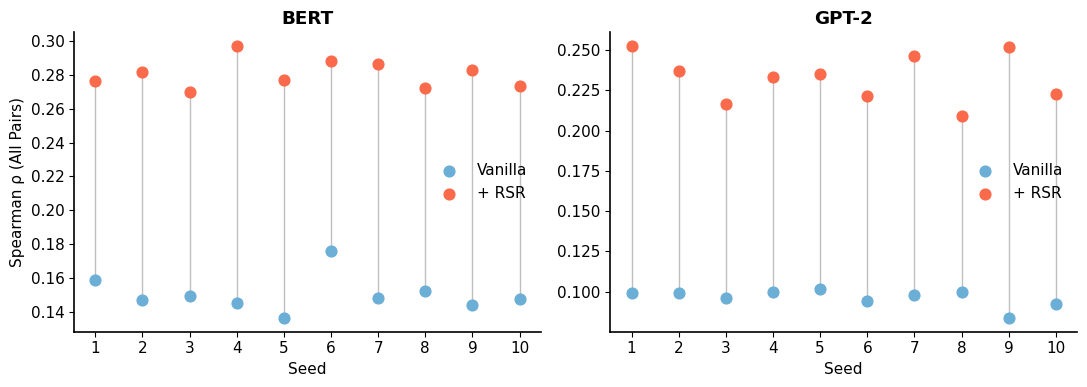

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# BERT
ax = axes[0]
seeds = df_bert['seed'].values
ax.scatter(seeds, df_bert['vanilla_all'], s=60, color='#6BAED6', label='Vanilla', zorder=3)
ax.scatter(seeds, df_bert['rsr_all'], s=60, color='#FB6A4A', label='+ RSR', zorder=3)
for i in range(len(seeds)):
    ax.plot([seeds[i], seeds[i]], 
            [df_bert['vanilla_all'].iloc[i], df_bert['rsr_all'].iloc[i]],
            color='gray', linewidth=1, alpha=0.5)
ax.set_xlabel('Seed')
ax.set_ylabel('Spearman ρ (All Pairs)')
ax.set_title('BERT', fontweight='bold')
ax.set_xticks(seeds)
ax.legend(frameon=False)

# GPT-2
ax = axes[1]
seeds = df_gpt2['seed'].values
ax.scatter(seeds, df_gpt2['vanilla_all'], s=60, color='#6BAED6', label='Vanilla', zorder=3)
ax.scatter(seeds, df_gpt2['rsr_all'], s=60, color='#FB6A4A', label='+ RSR', zorder=3)
for i in range(len(seeds)):
    ax.plot([seeds[i], seeds[i]], 
            [df_gpt2['vanilla_all'].iloc[i], df_gpt2['rsr_all'].iloc[i]],
            color='gray', linewidth=1, alpha=0.5)
ax.set_xlabel('Seed')
ax.set_title('GPT-2', fontweight='bold')
ax.set_xticks(seeds)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(fig_dir / 'fig3_robustness.pdf')
plt.savefig(fig_dir / 'fig3_robustness.png')
plt.show()

## Table: Full Results (LaTeX)

In [23]:
cats = ['all', 'both', 'one', 'neither']
cat_names = ['All pairs', 'Both in RSR', 'One in RSR', 'Neither in RSR']

print("="*80)
print("RESULTS TABLE")
print("="*80)

rows = []
for c, name in zip(cats, cat_names):
    rows.append({
        'Category': name,
        'BERT Van': f"{df_bert[f'vanilla_{c}'].mean():.3f}",
        'BERT RSR': f"{df_bert[f'rsr_{c}'].mean():.3f}±{df_bert[f'rsr_{c}'].std():.3f}",
        'BERT Δ': f"{df_bert[f'delta_{c}'].mean():+.3f}",
        'GPT2 Van': f"{df_gpt2[f'vanilla_{c}'].mean():.3f}",
        'GPT2 RSR': f"{df_gpt2[f'rsr_{c}'].mean():.3f}±{df_gpt2[f'rsr_{c}'].std():.3f}",
        'GPT2 Δ': f"{df_gpt2[f'delta_{c}'].mean():+.3f}",
    })

df_table = pd.DataFrame(rows)
print(df_table.to_string(index=False))
df_table.to_csv(fig_dir / 'results_table.csv', index=False)

print("\n" + "="*80)
print("LaTeX TABLE (copy this):")
print("="*80)
print(r"""\begin{table}[t]
\centering
\caption{SimLex-999 Spearman correlation ($\rho$) before and after RSR fine-tuning, across 10 random seeds.}
\label{tab:results}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{3}{c}{BERT} & \multicolumn{3}{c}{GPT-2} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Category & Vanilla & RSR & $\Delta$ & Vanilla & RSR & $\Delta$ \\
\midrule""")

for c, name in zip(cats, cat_names):
    bv = df_bert[f'vanilla_{c}'].mean()
    br = df_bert[f'rsr_{c}'].mean()
    bd = df_bert[f'delta_{c}'].mean()
    gv = df_gpt2[f'vanilla_{c}'].mean()
    gr = df_gpt2[f'rsr_{c}'].mean()
    gd = df_gpt2[f'delta_{c}'].mean()
    print(f"{name} & {bv:.3f} & {br:.3f} & {bd:+.3f} & {gv:.3f} & {gr:.3f} & {gd:+.3f} \\\\")

print(r"""\bottomrule
\end{tabular}
\end{table}""")

RESULTS TABLE
      Category BERT Van    BERT RSR BERT Δ GPT2 Van    GPT2 RSR GPT2 Δ
     All pairs    0.151 0.281±0.008 +0.130    0.096 0.233±0.015 +0.136
   Both in RSR    0.030 0.192±0.020 +0.161    0.041 0.182±0.017 +0.141
    One in RSR    0.239 0.387±0.012 +0.148    0.099 0.233±0.021 +0.133
Neither in RSR    0.230 0.405±0.023 +0.175    0.173 0.281±0.022 +0.107

LaTeX TABLE (copy this):
\begin{table}[t]
\centering
\caption{SimLex-999 Spearman correlation ($\rho$) before and after RSR fine-tuning, across 10 random seeds.}
\label{tab:results}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{3}{c}{BERT} & \multicolumn{3}{c}{GPT-2} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
Category & Vanilla & RSR & $\Delta$ & Vanilla & RSR & $\Delta$ \\
\midrule
All pairs & 0.151 & 0.281 & +0.130 & 0.096 & 0.233 & +0.136 \\
Both in RSR & 0.030 & 0.192 & +0.161 & 0.041 & 0.182 & +0.141 \\
One in RSR & 0.239 & 0.387 & +0.148 & 0.099 & 0.233 & +0.133 \\
Neither in RSR & 0.230 & 0.405 & +0.175 & 0.173 & 0

## Summary Statistics

In [24]:
print("KEY STATISTICS FOR PAPER TEXT:")
print("="*60)

print(f"\nBERT (n={len(df_bert)} seeds):")
print(f"  Overall improvement: Δρ = {df_bert['delta_all'].mean():+.3f} ± {df_bert['delta_all'].std():.3f}")
print(f"  Generalization (unseen): Δρ = {df_bert['delta_neither'].mean():+.3f} ± {df_bert['delta_neither'].std():.3f}")
print(f"  Seeds with positive Δ (all): {(df_bert['delta_all'] > 0).sum()}/{len(df_bert)}")
print(f"  Seeds with positive Δ (unseen): {(df_bert['delta_neither'] > 0).sum()}/{len(df_bert)}")

print(f"\nGPT-2 (n={len(df_gpt2)} seeds):")
print(f"  Overall improvement: Δρ = {df_gpt2['delta_all'].mean():+.3f} ± {df_gpt2['delta_all'].std():.3f}")
print(f"  Generalization (unseen): Δρ = {df_gpt2['delta_neither'].mean():+.3f} ± {df_gpt2['delta_neither'].std():.3f}")
print(f"  Seeds with positive Δ (all): {(df_gpt2['delta_all'] > 0).sum()}/{len(df_gpt2)}")
print(f"  Seeds with positive Δ (unseen): {(df_gpt2['delta_neither'] > 0).sum()}/{len(df_gpt2)}")

print(f"\nBERT vs GPT-2:")
print(f"  BERT advantage (all): {df_bert['rsr_all'].mean() - df_gpt2['rsr_all'].mean():+.3f}")
print(f"  BERT advantage (unseen): {df_bert['rsr_neither'].mean() - df_gpt2['rsr_neither'].mean():+.3f}")

KEY STATISTICS FOR PAPER TEXT:

BERT (n=10 seeds):
  Overall improvement: Δρ = +0.130 ± 0.013
  Generalization (unseen): Δρ = +0.175 ± 0.032
  Seeds with positive Δ (all): 10/10
  Seeds with positive Δ (unseen): 10/10

GPT-2 (n=10 seeds):
  Overall improvement: Δρ = +0.136 ± 0.017
  Generalization (unseen): Δρ = +0.107 ± 0.023
  Seeds with positive Δ (all): 10/10
  Seeds with positive Δ (unseen): 10/10

BERT vs GPT-2:
  BERT advantage (all): +0.048
  BERT advantage (unseen): +0.125


In [ ]:
print("\nFigures saved to:", fig_dir.absolute())
for f in sorted(fig_dir.glob('*')):
    print(f"  {f.name}")


Figures saved to: c:\Users\Jack\Documents\CursorProjects\Project3.1\Project3\figures
  bert_delta_boxplot.pdf
  bert_delta_boxplot.png
  bert_vanilla_vs_rsr.pdf
  bert_vanilla_vs_rsr.png
  fig1_main_results.pdf
  fig1_main_results.png
  fig2_improvement_by_category.pdf
  fig2_improvement_by_category.png
  fig3_robustness.pdf
  fig3_robustness.png
  fig4_scatter_before_after.pdf
  fig4_scatter_before_after.png
  fig5_slope_chart.pdf
  fig5_slope_chart.png
  fig6_seeds_lineplot.pdf
  fig6_seeds_lineplot.png
  fig_all_models_seeds.pdf
  fig_all_models_seeds.png
  fig_w2v_interleaved_seeds.pdf
  fig_w2v_interleaved_seeds.png
  results_table.csv


: 